In [4]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
pd.set_option('display.expand_frame_repr', False)

# Opciono: da ti ne skraćuje kolone u sredini (one tri tačkice ...)
pd.set_option('display.max_columns', None)

# Opciono: da povećaš širinu svake kolone ako je tekst dugačak
pd.set_option('display.max_colwidth', None)

In [6]:
member_df = pd.read_csv('member_stats_training.csv')
train_matches = pd.read_csv('clan_matches_training.csv')

# Priprema platformi (One-Hot Encoding)
platform_dummies = pd.get_dummies(member_df['registration_platform_specific'], prefix='plat')
member_df = pd.concat([member_df, platform_dummies], axis=1)
platform_cols = platform_dummies.columns.tolist()

payment_mapping = {
    '0) NonPayer': 0,
    '1) ExPayer': 1,
    '2) Minnow': 2,
    '3) Dolphin': 3,
    '4) Whale': 4,
    'Negative': -1
}
member_df['payment_numeric'] = member_df['dynamic_payment_segment'].map(payment_mapping)

In [7]:
def aggregate_clan_stats(df):
    # 1. Interakcije na nivou igrača
    df['player_eff_power'] = df['avg_stars_top_11_players'] * (1 + df['avg_training_bonus']/10)
    df['player_exp_contrib'] = df['player_eff_power'] * df['clan_multiplier']
    df['player_bonus_active_synergy'] = df['avg_training_bonus'] * df['days_active_last_7_days']
    df['player_bonus_efficiency'] = df['avg_training_bonus'] / (df['avg_stars_top_11_players'] + 1)

    # 2. Proširena logika grupisanja
    agg_logic = {
        'avg_stars_top_11_players': ['mean', 'min', 'max', 'std'],
        'avg_training_bonus': [
            'mean', 'min', 'max', 'std', 'median', 'skew'
        ],
        'days_active_last_7_days': ['mean', 'min', 'max', 'std', 'skew'],
        'clan_multiplier': ['sum', 'mean', 'max', 'std'],
        'player_eff_power': ['mean', 'max'],
        'player_exp_contrib': ['mean', 'sum'],
        'player_bonus_active_synergy': ['mean'],
        'player_bonus_efficiency': ['mean']
    }

    clan_feats = df.groupby('clan_id').agg(agg_logic)
    
    # Sređivanje imena kolona
    clan_feats.columns = [
        'stars_11_mean', 'stars_11_min', 'stars_11_max', 'stars_11_std',
        'bonus_mean', 'bonus_min', 'bonus_max', 'bonus_std', 'bonus_median', 'bonus_skew',
        'activity_7_mean', 'activity_7_min', 'activity_7_max', 'activity_7_std','activity_7_skew',
        'multiplier_sum', 'multiplier_mean', 'multiplier_max', 'multiplier_std',
        'eff_power_mean', 'eff_power_max',
        'exp_contrib_mean', 'exp_contrib_sum',
        'bonus_active_synergy', 'bonus_efficiency'
    ]
    clan_feats = clan_feats.reset_index()

    # 3. Izvedene metrike za distribuciju snage
    # Razlika između proseka i medijane pokazuje da li par igrača kvari prosek celom timu
    clan_feats['bonus_mean_median_diff'] = clan_feats['bonus_mean'] - clan_feats['bonus_median']
    
    
    clan_feats['bonus_range'] = clan_feats['bonus_max'] - clan_feats['bonus_min']
    clan_feats['bonus_dropoff'] = clan_feats['bonus_mean'] - clan_feats['bonus_min']
    
    return clan_feats

# --- IZVRŠAVANJE OSTAJE ISTO ---
train_clan_features = aggregate_clan_stats(member_df)

df_final = train_matches.merge(train_clan_features, left_on='clan_1_id', right_on='clan_id')
df_final = df_final.merge(train_clan_features, left_on='clan_2_id', right_on='clan_id', suffixes=('_c1', '_c2'))

# Automatsko pravljenje DIFF i RATIO kolona
base_stats = [c for c in train_clan_features.columns if c != 'clan_id']
final_feature_list = []

for col in base_stats:
    c1, c2 = f"{col}_c1", f"{col}_c2"
    df_final[f"{col}_diff"] = df_final[c1] - df_final[c2]
    df_final[f"{col}_ratio"] = (df_final[c1] + 0.01) / (df_final[c2] + 0.01)
    final_feature_list.extend([f"{col}_diff", f"{col}_ratio"])

print(f"Dataset spreman sa {len(final_feature_list)} kolona.")

Dataset spreman sa 56 kolona.


In [102]:
df_final.head()

,clan_1_id,clan_2_id,clan_1_points,clan_2_points,clan_winner,c1_won,clan_id_c1,stars_11_mean_c1,stars_11_min_c1,stars_11_max_c1,stars_11_std_c1,bonus_mean_c1,bonus_min_c1,bonus_max_c1,bonus_std_c1,bonus_median_c1,bonus_skew_c1,activity_7_mean_c1,activity_7_min_c1,activity_7_max_c1,activity_7_std_c1,activity_7_proizvod_c1,multiplier_sum_c1,multiplier_mean_c1,multiplier_max_c1,multiplier_std_c1,eff_power_mean_c1,eff_power_max_c1,exp_contrib_mean_c1,exp_contrib_sum_c1,bonus_active_synergy_c1,bonus_efficiency_c1,bonus_mean_median_diff_c1,bonus_range_c1,bonus_dropoff_c1,clan_id_c2,stars_11_mean_c2,stars_11_min_c2,stars_11_max_c2,stars_11_std_c2,bonus_mean_c2,bonus_min_c2,bonus_max_c2,bonus_std_c2,bonus_median_c2,bonus_skew_c2,activity_7_mean_c2,activity_7_min_c2,activity_7_max_c2,activity_7_std_c2,activity_7_proizvod_c2,multiplier_sum_c2,multiplier_mean_c2,multiplier_max_c2,multiplier_std_c2,eff_power_mean_c2,eff_power_max_c2,exp_contrib_mean_c2,exp_contrib_sum_c2,bonus_active_synergy_c2,bonus_efficiency_c2,bonus_mean_median_diff_c2,bonus_range_c2,bonus_dropoff_c2,stars_11_mean_diff,stars_11_mean_ratio,stars_11_min_diff,stars_11_min_ratio,stars_11_max_diff,stars_11_max_ratio,stars_11_std_diff,stars_11_std_ratio,bonus_mean_diff,bonus_mean_ratio,bonus_min_diff,bonus_min_ratio,bonus_max_diff,bonus_max_ratio,bonus_std_diff,bonus_std_ratio,bonus_median_diff,bonus_median_ratio,bonus_skew_diff,bonus_skew_ratio,activity_7_mean_diff,activity_7_mean_ratio,activity_7_min_diff,activity_7_min_ratio,activity_7_max_diff,activity_7_max_ratio,activity_7_std_diff,activity_7_std_ratio,activity_7_proizvod_diff,activity_7_proizvod_ratio,multiplier_sum_diff,multiplier_sum_ratio,multiplier_mean_diff,multiplier_mean_ratio,multiplier_max_diff,multiplier_max_ratio,multiplier_std_diff,multiplier_std_ratio,eff_power_mean_diff,eff_power_mean_ratio,eff_power_max_diff,eff_power_max_ratio,exp_contrib_mean_diff,exp_contrib_mean_ratio,exp_contrib_sum_diff,exp_contrib_sum_ratio,bonus_active_synergy_diff,bonus_active_synergy_ratio,bonus_efficiency_diff,bonus_efficiency_ratio,bonus_mean_median_diff_diff,bonus_mean_median_diff_ratio,bonus_range_diff,bonus_range_ratio,bonus_dropoff_diff,bonus_dropoff_ratio
0,clan_7201,clan_25726,0,72,2,0,clan_7201,4.933925,4.059685,5.995915,0.734873,8.250000,0.0,12.5,5.027425,10.0,-1.037632,4.833333,0,7,3.060501,10752,15,2.500000,3,0.836660,9.204297,13.490809,24.953844,149.723063,49.50,1.350779,-1.750000,12.5,8.250000,clan_25726,4.723028,3.161321,6.027782,1.237120,6.166667,0.0,12.0,5.600595,6.50,-1.015149e-01,4.666667,0,7,3.614784,4096,13,2.166667,3,1.329160,8.172599,13.261120,21.819355,130.916131,43.166667,0.942032,-0.333333,12.0,6.166667,0.210897,1.044559,0.898364,1.283277,-0.031867,0.994722,-0.502247,0.597274,2.083333,1.337291,0.0,1.000000,0.5,1.041632,-0.573170,0.897841,3.50,1.537634,-0.936117,11.229118,0.166667,1.035638,0,1.000000,0,1.0,-0.554283,0.847085,6656,2.624996,2,1.153728,0.333333,1.153139,0,1.0,-0.492500,0.632232,1.031697,1.126084,0.229689,1.017307,3.134489,1.143591,18.806931,1.143645,6.333333,1.146684,0.408748,1.429343,-1.416667,5.381443,0.5,1.041632,2.083333,1.337291
1,clan_5202,clan_16269,0,78,2,0,clan_5202,4.437778,3.222424,5.609261,1.024925,3.000000,0.0,11.5,4.909175,0.0,1.392092,2.666667,0,7,3.076795,240,12,2.000000,3,1.264911,6.089453,12.059910,14.740339,88.442036,17.75,0.461352,3.000000,11.5,3.000000,clan_16269,4.535998,3.028739,5.643854,1.057368,4.666667,0.0,11.5,5.363457,3.25,3.345458e-01,4.666667,0,7,3.614784,4096,15,2.500000,3,0.836660,6.980348,12.134287,19.314055,115.884327,32.666667,0.755556,1.416667,11.5,4.666667,-0.098220,0.978394,0.193685,1.063738,-0.034594,0.993881,-0.032443,0.969605,-1.666667,0.643621,0.0,1.000000,0.0,1.000000,-0.454282,0.915458,-3.25,0.003067,1.057546,4.069393,-2.000000,0.572345,0,1.000000,0,1.0,-0.537990,0.851580,-3856,0.058596,-3,0.800133,-0.500000,0.800797,0,1.0,0.428251,1.505812,-0.890895,0.872554,-0.074377,0.993876,-4.573715,0.763315,-27.442291,0.763213,-14.916667,0.543507,-0.29420

In [10]:
feature_short = ['bonus_min_ratio','bonus_min_diff','bonus_mean_ratio']
# 2. Priprema podataka
X = df_final[final_feature_list]
y = df_final['clan_winner'] - 1

# Težine na osnovu razlike u poenima
W = (df_final['clan_1_points'] - df_final['clan_2_points']).abs() + 1

X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X, y, W, test_size=0.25, random_state=0
)

# 3. Trening sa tvojim najboljim parametrima
model_all = XGBClassifier(
    n_estimators=200, 
    learning_rate=0.02, 
    max_depth=5,    
    subsample=0.9,
    reg_alpha=20,   
    reg_lambda=10,
    gamma=1,
    colsample_bytree=0.8 
)

model_all.fit(X_train, y_train, sample_weight=w_train)

# 4. Evaluacija
val_preds = model_all.predict(X_val)
val_probas = model_all.predict_proba(X_val).max(axis=1)

print(f"Ukupni Accuracy sa SVIM feature-ima: {accuracy_score(y_val, val_preds):.4f}")

# Provera na 70% threshold-u
conf_mask = val_probas >= 0.7
if conf_mask.any():
    print(f"Accuracy na 70% thresholdu (All features): {accuracy_score(y_val[conf_mask], val_preds[conf_mask]):.4f}")
    print(f"Pokrivenost: {conf_mask.mean()*100:.2f}%")

Ukupni Accuracy sa SVIM feature-ima: 0.5776
Accuracy na 70% thresholdu (All features): 0.6971
Pokrivenost: 29.63%


C:\Users\User\AppData\Local\Temp\ipykernel_14168\4186386089.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='magma')


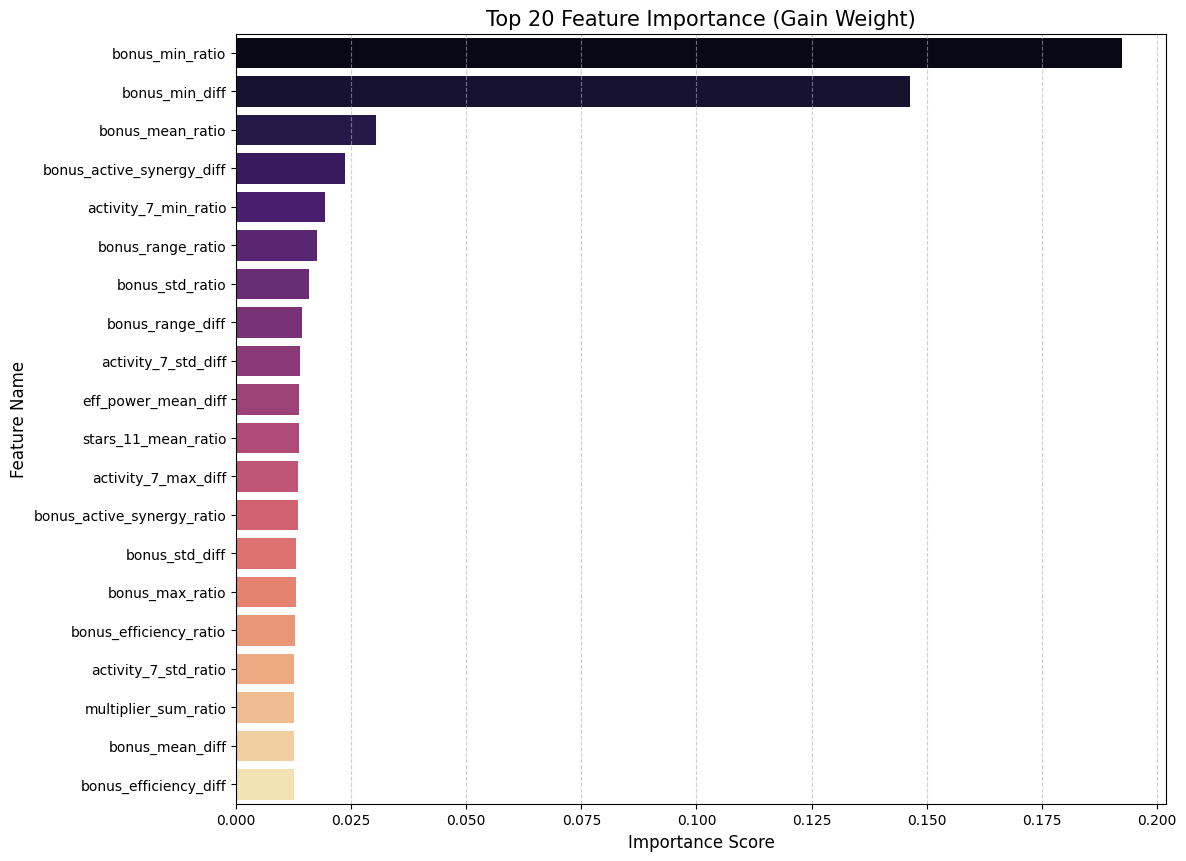

Ukupno feature-a u modelu: 56
Feature-i koji zapravo 'rade' (score > 0): 56


In [129]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Uzimamo importances direktno preko sklearn API-ja (najsigurniji način)
importances = model_all.feature_importances_
feature_names = X_train.columns

# 2. Pravimo DataFrame radi lakšeg sortiranja
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Vizuelizacija Top 20 najbitnijih
plt.figure(figsize=(12, 10))
sns.barplot(x='Importance', y='Feature', data=df_importance.head(20), palette='magma')

plt.title('Top 20 Feature Importance (Gain Weight)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 4. Provera koliko feature-a zapravo doprinosi (oni sa score > 0)
active_features = df_importance[df_importance['Importance'] > 0]
print(f"Ukupno feature-a u modelu: {len(feature_names)}")
print(f"Feature-i koji zapravo 'rade' (score > 0): {len(active_features)}")

In [111]:
%pip install optuna

  Using cached alembic-1.18.4-py3-none-any.whl.metadata (7.2 kB)
  Using cached colorlog-6.10.1-py3-none-any.whl.metadata (11 kB)
Using cached alembic-1.18.4-py3-none-any.whl (263 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 16.0 MB/s  0:00:00
Using cached colorlog-6.10.1-py3-none-any.whl (11 kB)

   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ---------------------------------------- 0/6 [Mako]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   ------ --------------------------------- 1/6 [greenlet]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ------------------- 3/6 [sqlalchemy]
   -------------------- ----------------

In [113]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

def objective(trial):
    # 1. Definisanje prostora pretrage (Search Space)
    param = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'gamma': trial.suggest_float('gamma', 0.1, 10, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 50.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 50.0, log=True),
        'random_state': 47,
        'n_jobs': -1,
        'eval_metric': 'logloss'
    }

    # 2. Inicijalizacija modela
    model = XGBClassifier(**param)

    # 3. Trening sa tvojim težinama (w_train)
    model.fit(X_train, y_train, sample_weight=w_train)

    # 4. Predikcija i evaluacija
    preds = model.predict(X_val)
    accuracy = accuracy_score(y_val, preds)

    return accuracy

# 5. Pokretanje Optuna studije
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50) # Možeš povećati na 100 za još bolji rezultat

print("Najbolji parametri:", study.best_params)
print(f"Najbolji Accuracy: {study.best_value:.4f}")

# 6. Automatsko treniranje finalnog modela sa najboljim parametrima
best_model = XGBClassifier(**study.best_params)
best_model.fit(X_train, y_train, sample_weight=w_train)

[I 2026-04-29 22:21:47,273] A new study created in memory with name: no-name-12f1533e-d096-4b64-8c1c-5d2c6d54c974
[I 2026-04-29 22:21:49,003] Trial 0 finished with value: 0.5692328804720735 and parameters: {'n_estimators': 250, 'max_depth': 6, 'learning_rate': 0.050319311818448835, 'subsample': 0.6612345496873732, 'colsample_bytree': 0.6363149242440947, 'min_child_weight': 4, 'gamma': 1.0455351835123565, 'reg_alpha': 40.34582712748724, 'reg_lambda': 0.0021663107216812172}. Best is trial 0 with value: 0.5692328804720735.
[I 2026-04-29 22:22:03,830] Trial 1 finished with value: 0.568546727048168 and parameters: {'n_estimators': 480, 'max_depth': 10, 'learning_rate': 0.035679749603146356, 'subsample': 0.9351740006446257, 'colsample_bytree': 0.6303367412958312, 'min_child_weight': 1, 'gamma': 0.13342570585812802, 'reg_alpha': 46.14083046139695, 'reg_lambda': 0.2596569647762024}. Best is trial 0 with value: 0.5692328804720735.
[I 2026-04-29 22:22:05,795] Trial 2 finished with value: 0.57348

Najbolji parametri: {'n_estimators': 138, 'max_depth': 4, 'learning_rate': 0.021925841251406796, 'subsample': 0.6810577805450557, 'colsample_bytree': 0.9998023692784264, 'min_child_weight': 12, 'gamma': 2.1819947014706456, 'reg_alpha': 0.01722397062685884, 'reg_lambda': 0.16146536439639875}
Najbolji Accuracy: 0.5842


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.9998023692784264
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [30]:
feature_short = ['bonus_min_ratio','bonus_min_diff','bonus_mean_ratio']
# 2. Priprema podataka
X = df_final[feature_short]
y = df_final['clan_winner'] - 1

# Težine na osnovu razlike u poenima
W = (df_final['clan_1_points'] - df_final['clan_2_points']).abs() + 1

X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X, y, W, test_size=0.25, random_state=0
)

# 3. Trening sa tvojim najboljim parametrima
model_all = XGBClassifier(
    n_estimators=138, 
    learning_rate=0.022, 
    max_depth=4,    
    subsample=0.68,
    reg_alpha=0.0172,   
    reg_lambda=0.161,
    gamma=2.182,
    min_child_weight=12,
    colsample_bytree=1 
)

model_all.fit(X_train, y_train, sample_weight=w_train)

# 4. Evaluacija
val_preds = model_all.predict(X_val)
val_probas = model_all.predict_proba(X_val).max(axis=1)

print(f"Ukupni Accuracy sa SVIM feature-ima: {accuracy_score(y_val, val_preds):.4f}")

# Provera na 70% threshold-u
conf_mask = val_probas >= 0.7
if conf_mask.any():
    print(f"Accuracy na 70% thresholdu (All features): {accuracy_score(y_val[conf_mask], val_preds[conf_mask]):.4f}")
    print(f"Pokrivenost: {conf_mask.mean()*100:.2f}%")

Ukupni Accuracy sa SVIM feature-ima: 0.5866
Accuracy na 70% thresholdu (All features): 0.7051
Pokrivenost: 30.11%


In [141]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# 1. Definisanje modela sa tvojim novim parametrima
cv_model = XGBClassifier(
    n_estimators=138, 
    learning_rate=0.022, 
    max_depth=4,    
    subsample=0.68,
    reg_alpha=0.0172,   
    reg_lambda=0.161,
    gamma=2.182,
    min_child_weight=12,
    colsample_bytree=1,
    random_state=47,
    eval_metric='logloss'
)

# 2. Podešavanje Cross-Validacije (5 foldova je standard)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=47)

acc_scores = []
conf_70_scores = []

print(f"{'Fold':<5} | {'Train Acc':<10} | {'Val Acc':<10} | {'Acc@70%':<10} | {'Coverage':<10}")
print("-" * 55)

# 3. CV Petlja
# Koristimo X i y (ceo dataset pre split-a) ili X_train/y_train ako čuvaš finalni test set
for i, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    # Split podataka za ovaj fold
    X_tr_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_tr_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    w_tr_cv = W.iloc[train_idx] # Težine za trening deo

    # Trening
    cv_model.fit(X_tr_cv, y_tr_cv, sample_weight=w_tr_cv)

    # Predikcije
    preds_tr = cv_model.predict(X_tr_cv)
    preds_val = cv_model.predict(X_val_cv)
    probas_val = cv_model.predict_proba(X_val_cv).max(axis=1)

    # Metrike
    acc_tr = accuracy_score(y_tr_cv, preds_tr)
    acc_val = accuracy_score(y_val_cv, preds_val)
    acc_scores.append(acc_val)
    
    # Provera na 70% thresholdu za ovaj fold
    mask = probas_val >= 0.7
    if mask.any():
        acc_70 = accuracy_score(y_val_cv[mask], preds_val[mask])
        coverage = mask.mean() * 100
        conf_70_scores.append(acc_70)
    else:
        acc_70 = 0
        coverage = 0

    print(f"{i+1:<5} | {acc_tr:<10.4f} | {acc_val:<10.4f} | {acc_70:<10.4f} | {coverage:<8.2f}%")

print("-" * 55)
print(f"Srednji Accuracy: {np.mean(acc_scores):.4f} (+/- {np.std(acc_scores):.4f})")
if conf_70_scores:
    print(f"Srednji Acc@70%: {np.mean(conf_70_scores):.4f}")

Fold  | Train Acc  | Val Acc    | Acc@70%    | Coverage  
-------------------------------------------------------
1     | 0.5908     | 0.5955     | 0.7086     | 29.31   %
2     | 0.5900     | 0.5926     | 0.7353     | 26.99   %
3     | 0.5918     | 0.5889     | 0.6992     | 29.70   %
4     | 0.5902     | 0.5876     | 0.7028     | 29.24   %
5     | 0.5946     | 0.5763     | 0.7055     | 28.66   %
-------------------------------------------------------
Srednji Accuracy: 0.5882 (+/- 0.0066)
Srednji Acc@70%: 0.7103
